In [96]:
import numpy as np
import pandas as pd

df=pd.read_csv('cleaned_data.csv')
def calculate_critic_weights(df, columns):
    # 1. Min-Max Normalization
    matrix = df[columns].copy()
    norm_matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-9)
    
    # 2. Calculate Standard Deviation (Contrast Intensity)
    std_devs = norm_matrix.std(axis=0)
    
    # 3. Calculate Correlation Matrix (Inter-criteria Correlation)
    corr_matrix = norm_matrix.corr()
    
    # 4. Calculate Conflict Layer sum(1 - r_jk)
    conflict = (1 - corr_matrix).sum(axis=1)
    
    # 5. Calculate Information Quantity (C_j)
    c_j = std_devs * conflict
    
    # 6. Calculate Final Objective Weights
    weights = c_j / c_j.sum()
    
    return weights

In [97]:
weights = calculate_critic_weights(df,df.columns.drop('id'))
print(weights)

Average Revolve Balance in last 12m     0.045284
Cancellation Calls in last 12m          0.072015
Cancellation Calls due to Collection    0.057622
Rewards Points Balance                  0.030109
Total Spend in last 12m                 0.044692
Airlines Spend in 12m                   0.035573
Other Spend in 12m                      0.036368
Entertainment Spend in 12m              0.035672
Lodging Spend in 12m                    0.035162
Dining Spend in 12m                     0.037587
Average Risk Score in 12m               0.046206
Login Counts to website                 0.042985
Lounge Access Count                     0.048370
Credits used in airlines                0.056302
Cab benefits usage                      0.055952
Entertainment Credit Used Amount        0.051632
Total Lend Line Amount                  0.028092
Total Consumer Lend Line Amount         0.025267
Number of Supplementary Accounts        0.051406
Count of Active Charge Cards            0.064873
Rewards point redeem

In [98]:
a=df.drop(columns=['id'])

In [99]:
n=pd.DataFrame(weights,columns=['weight'])
n['features']=a.columns

In [100]:
n

,weight,features
Average Revolve Balance in last 12m,0.045284,Average Revolve Balance in last 12m
Cancellation Calls in last 12m,0.072015,Cancellation Calls in last 12m
Cancellation Calls due to Collection,0.057622,Cancellation Calls due to Collection
Rewards Points Balance,0.030109,Rewards Points Balance
Total Spend in last 12m,0.044692,Total Spend in last 12m
Airlines Spend in 12m,0.035573,Airlines Spend in 12m
Other Spend in 12m,0.036368,Other Spend in 12m
Entertainment Spend in 12m,0.035672,Entertainment Spend in 12m
Lodging Spend in 12m,0.035162,Lodging Spend in 12m
Dining Spend in 12m,0.037587,Dining Spend in 12m


In [101]:
a

,Average Revolve Balance in last 12m,Cancellation Calls in last 12m,Cancellation Calls due to Collection,Rewards Points Balance,Total Spend in last 12m,Airlines Spend in 12m,Other Spend in 12m,Entertainment Spend in 12m,Lodging Spend in 12m,Dining Spend in 12m,...,Credits used in airlines,Cab benefits usage,Entertainment Credit Used Amount,Total Lend Line Amount,Total Consumer Lend Line Amount,Number of Supplementary Accounts,Count of Active Charge Cards,Rewards point redeemed in 12months,Emails Open in Last 6 months,Emails Clicked in Last 6 months
0,0.000000,0,1,98615.44,5620.938246,0.0000,0.00000,0.0000,0.0000,0.0000,...,0.0000,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.00,2.0,0.0
1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.0000,494.8428,...,196.0000,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.00,3.0,0.0
2,1224.690475,0,1,50705.19,16.160000,0.0000,0.00000,0.0000,0.0000,0.0000,...,0.0000,0.0,19.646836,21728.0,19800.0,1.0,1.0,11186.36,9.0,0.0
3,0.000000,1,0,50705.19,1635.316863,3231.1968,-269.15308,0.0000,0.0000,48.5520,...,0.0000,0.0,9.143074,12348.0,12474.0,2.0,1.0,11186.36,5.0,0.0
4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.9740,5354.3280,...,0.0000,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.000000,0,0,140995.62,0.000000,26017.2042,84888.10260,2318.6227,5343.4252,12996.2722,...,12.7500,4.0,61.827262,21728.0,19800.0,1.0,1.0,0.00,1.0,0.0
499996,14524.638800,0,0,16548.20,387.496932,7941.0602,52191.75780,483.7698,7404.7410,21650.5820,...,0.0000,0.0,64.403398,21728.0,19800.0,2.0,2.0,65067.84,6.0,0.0
499997,0.000000,0,0,79328.70,6654.585300,0.0000,1529.98580,0.0000,0.0000,0.0000,...,0.0000,1.0,64.403398,21728.0,19800.0,1.0,1.0,14212.97,15.0,0.0
499998,17967.726330,0,0,2.10,4393.267105,0.0000,322.22100,0.0000,0.0000,3.1680,...,0.0000,0.0,61.183228,21728.0,19800.0,1.0,1.0,0.00,4.0,0.0


In [102]:
interest=['Average Revolve Balance in last 12m','Total Lend Line Amount','Total Consumer Lend Line Amount','Count of Active Charge Cards']
moneyflow=['Total Spend in last 12m','Airlines Spend in 12m','Other Spend in 12m','Entertainment Spend in 12m','Lodging Spend in 12m','Dining Spend in 12m']
cost=['Rewards Points Balance','Lounge Access Count','Credits used in airlines','Cab benefits usage','Entertainment Credit Used Amount','Rewards point redeemed in 12months']
engagement=['Login Counts to website','Number of Supplementary Accounts','Emails Open in Last 6 months','Emails Clicked in Last 6 months']
risk=['Cancellation Calls in last 12m','Cancellation Calls due to Collection','Average Risk Score in 12m']

In [103]:
#weight_cost=[]
#weight_engagement=[]
#weight_interest=[]
#weight_moneyflow=[]
#weight_risk=[]
for c in interest:
    weight_interest=n['weight'].where(n['features'].isin(interest)).dropna()
for c in moneyflow:
    weight_moneyflow=n['weight'].where(n['features'].isin(moneyflow)).dropna()
for c in cost:
    weight_cost=n['weight'].where(n['features'].isin(cost)).dropna()
for c in engagement:
    weight_engagement=n['weight'].where(n['features'].isin(engagement)).dropna()
for c in risk:
    weight_risk=n['weight'].where(n['features'].isin(risk)).dropna()

In [105]:
weight_interest

Average Revolve Balance in last 12m    0.045284
Total Lend Line Amount                 0.028092
Total Consumer Lend Line Amount        0.025267
Count of Active Charge Cards           0.064873
Name: weight, dtype: float64

In [106]:
a[interest]

,Average Revolve Balance in last 12m,Total Lend Line Amount,Total Consumer Lend Line Amount,Count of Active Charge Cards
0,0.000000,1960.0,1900.0,1.0
1,0.000000,34300.0,34650.0,2.0
2,1224.690475,21728.0,19800.0,1.0
3,0.000000,12348.0,12474.0,1.0
4,3824.366700,3672.0,3528.0,1.0
...,...,...,...,...
499995,0.000000,21728.0,19800.0,1.0
499996,14524.638800,21728.0,19800.0,2.0
499997,0.000000,21728.0,19800.0,1.0
499998,17967.726330,21728.0,19800.0,1.0


In [107]:
Interest=0
MoneyFlow=0
Cost=0
Engagement=0
Risk=0
for i in range(len(interest)):
    Interest=Interest+weight_interest[i]*a[interest[i]]
for i in range(len(moneyflow)):
    MoneyFlow=MoneyFlow+weight_moneyflow[i]*a[moneyflow[i]]
for i in range(len(cost)):
    Cost=Cost+weight_cost[i]*a[cost[i]]
for i in range(len(engagement)):
    Engagement=Engagement+weight_engagement[i]*a[engagement[i]]
for i in range(len(risk)):
    Risk=Risk+weight_risk[i]*a[risk[i]]

/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_18694/587818213.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Interest=Interest+weight_interest[i]*a[interest[i]]
/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_18694/587818213.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MoneyFlow=MoneyFlow+weight_moneyflow[i]*a[moneyflow[i]]
/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_18694/587818213.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior).

In [118]:
Profitability=(Interest+MoneyFlow-Cost)*(1-Risk) + Engagement
Profitability1=Interest+MoneyFlow+Engagement-Cost-Risk

In [120]:
Profitability.describe(),Profitability1.describe()

(count    500000.000000
 mean       -967.151362
 std        4536.404196
 min      -32001.647316
 25%       -1081.075436
 50%        -250.122798
 75%         990.276408
 max       12679.861541
 dtype: float64,
 count    500000.000000
 mean       -988.929759
 std        4582.339656
 min      -32257.265344
 25%       -1117.243545
 50%        -256.629566
 75%        1005.213143
 max       12682.592489
 dtype: float64)

(<Axes: ylabel='Count'>, <Axes: ylabel='Count'>)

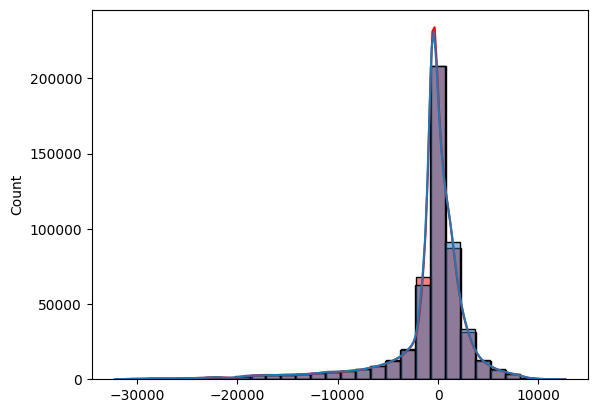

In [121]:
import seaborn as sns
sns.histplot(Profitability,kde=True,bins=30,color='red'),sns.histplot(Profitability1,kde=True,bins=30)

In [124]:
Profitability.sort_values(ascending=False,inplace=True),Profitability1.sort_values(ascending=False,inplace=True)

(None, None)

(<Axes: ylabel='Count'>, <Axes: ylabel='Count'>)

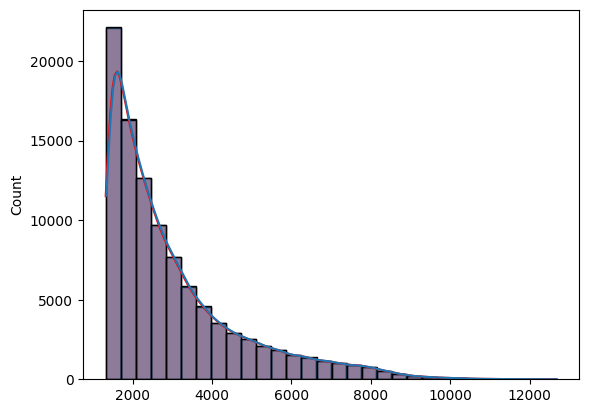

In [126]:
sns.histplot(Profitability[0:100000],bins=30,kde=True,color='r'),sns.histplot(Profitability1[0:100000],bins=30,kde=True)

In [127]:
a1=Profitability
a2=Profitability1

In [130]:
n=pd.DataFrame(a1,columns=['score'])
n

,score
488787,12679.861541
123960,12074.740643
363514,11829.661721
483743,11824.853438
130685,11809.505730
...,...
131511,-31685.666856
482662,-31710.205769
453522,-31756.897094
191496,-31876.141332


In [131]:
n['ID']=n.index

In [132]:
n['rank']=a1

In [136]:
n

,score,ID,rank
488787,12679.861541,488787,12679.861541
123960,12074.740643,123960,12074.740643
363514,11829.661721,363514,11829.661721
483743,11824.853438,483743,11824.853438
130685,11809.505730,130685,11809.505730
...,...,...,...
131511,-31685.666856,131511,-31685.666856
482662,-31710.205769,482662,-31710.205769
453522,-31756.897094,453522,-31756.897094
191496,-31876.141332,191496,-31876.141332


In [137]:
n.sort_values(by='rank',ascending=False,inplace=True)

In [138]:
n['Prediction']=n['rank'].rank(pct=True)
n.head(5)

,score,ID,rank,Prediction
488787,12679.861541,488787,12679.861541,1.000000
123960,12074.740643,123960,12074.740643,0.999998
363514,11829.661721,363514,11829.661721,0.999996
483743,11824.853438,483743,11824.853438,0.999994
130685,11809.505730,130685,11809.505730,0.999992


In [139]:
n.sort_values(by='ID',ascending=True,inplace=True)

In [141]:
n=n.drop(columns=['score','rank'])
n

,ID,Prediction
0,0,0.154708
1,1,0.141194
2,2,0.331648
3,3,0.264708
4,4,0.283322
...,...,...
499995,499995,0.837166
499996,499996,0.906408
499997,499997,0.215864
499998,499998,0.880350


In [142]:
n.to_excel('Predictions.xlsx',index=False)

In [143]:
responses = {
    "Variables Used":
    "Average Revolve Balance (f1), Total Spend (f5), Category Spend (f6-f10), Risk Score (f11), Reward Features (f4,f13-f16,f21), Lending Features (f17-f20), Engagement Features (f2,f12,f22,f23).",

    "Profitability Equation":
    "Profitability = (revenue-cost) * (1-risk factor) + engagement bonus",

    "Prediction Logic":
    "Features were converted into weighted scores. Positive features retained percentile ranks while risk/cost features were reversed. Weighted pillar scores were combined to obtain the final profitability score.",

    "Variable Selection Logic":
    "Variables were selected using business understanding of the Premier Card product, exploratory data analysis, missing-value analysis, feature correlation and domain relevance.",

    "Coefficient/Weight Derivation":
    "Weights were assigned using EWM. Revenue received the highest importance followed by Risk, Benefit Cost, Relationship and Engagement.",

    "Feature Transformations":
    "Median/mode imputation, zero imputation for structural missing values, missing indicators, engineered features (Spend Diversity, Benefit Breadth and Click Through Rate), percentile normalization.",

    "Business Logic":
    "Highly profitable customers are expected to generate high spend, maintain low credit risk, build long-term relationships and actively engage with premium card benefits.",

    "Assumptions":
    "Missing values in several features represent absence of activity. Percentile ranking provides a robust common scale across heterogeneous variables.",

    "Validation Approach":
    "Validated using exploratory data analysis, feature correlation analysis, customer profile comparison and multiple profitability framework experiments."
}

In [144]:
f=pd.DataFrame(list(responses.items()),columns=['Section','Response'])

In [145]:
f.to_excel('Profitability Framework.xlsx',index=False)

In [146]:
import pandas as pd

# 1. Define your file names
file_one = "Profitability Framework.xlsx"
file_two = "Predictions.xlsx"  # Change this to your second file's name
output_file = "Final.xlsx"

# 2. Read the data from both files
# (If your files have multiple sheets, specify sheet_name='SheetName')
df1 = pd.read_excel(file_one)
df2 = pd.read_excel(file_two)

# 3. Write them into one file with two different sheets
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df2.to_excel(writer, index=False, sheet_name="Predictions")
    df1.to_excel(writer, index=False, sheet_name="Profitability Framework")

print(f"Successfully merged into: {output_file}")


Successfully merged into: Final.xlsx
